## Assignment 2: $k$ Nearest Neighbor

### Austin Chinn


In [163]:
# Import data

import urllib.request
import os
import zipfile
import os
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier, KNeighborsRegressor
from sklearn.metrics import confusion_matrix, accuracy_score
from sklearn.metrics import ConfusionMatrixDisplay, mean_squared_error
from sklearn.preprocessing import StandardScaler



def download_data(force=False):
    """Download and extract course data from Zenodo."""

    zip_path = 'data.zip'
    data_dir = './data'

    if not os.path.exists(zip_path) or force:
        print("Downloading course data...")
        urllib.request.urlretrieve(
            'https://zenodo.org/records/18235955/files/data.zip?download=1',
            zip_path
        )
        print("Download complete")

    if not os.path.exists(data_dir) or force:
        print("Extracting data files...")
        with zipfile.ZipFile(zip_path, 'r') as zip_ref:
            zip_ref.extractall(data_dir)
        print("Data extracted")

    return data_dir


if __name__ == "__main__":
    download_data()

**Q1.** Please answer the following questions.
1. What is the difference between regression and classification?

Regression aims to predict a numeric y from one or more numeric x using a trained algorithm, where classification aims to place y into predefined categories using one or more categorical or numeric x.

2. What is a confusion table/matrix? What does it help us understand about a model's performance?

For classification, a confusion table compares predicted categories with actual categories to help understand how accurate the model is, and where errors in classification most often occur.

3. What is Accuracy? Why might it not be entirely sufficient to evaluate a classifer's predictive performance?

Accuracy is the overall proportion of correct predictions to total predictions. This evaluation falls short when certain types of misclassification are more harmful than others (false pos vs. false neg.) and when one class size is much larger than the other (potentially showing overall accurate model when one small class is inaccurate)

4. What does the root mean squared error quantify about a particular model?

The degree to which the model is inaccurate in the same units as the y, with squaring adding penalty to more extreme prediction inaccuracies.

5. What are overfitting and underfitting?

Overfitting is the training of a model on too many variables such that the model is not generalizable and introduces issues derived from irrelevant and confounding datasets

Underfitting is the training of a model on too few variables, such that it cannot capture the full picture of influential factors and is inaccurate.

6. Why does splitting the data into training and testing sets, and choosing $k$ by evaluating accuracy or RMSE on the test set, improve model performance?

Splitting the model into training and testing sets ensures the model is not fit specifically to your dataset and not generalizable

Choosing k based on accuracy in tests allows for the discernment of best k value to balance specificity and predictive generalizability.

7. With classification, we can report a class label as a prediction or a probability distribution over class labels. Please explain the strengths and weaknesses of each approach.

While predictions are easy to interpret and immediately actionable, they don't express uncertainty.

Probability distributions show the error of each prediction, allowing for more user input in decision making, but they are more difficult to interpret and it is harder to improve model accuracy as a result.

**Q2.** This is a case study on $k$ nearest neighbor classification, using the `land_mines.csv` data.

The data consists of a label, `mine_type`, taking integer values 1 to 5, and three properties of the mine, `voltage`, `height` and `soil`. We want to predict the kind of mine from data about it. Imagine working for the DOD or a humanitarian aid agency, trying to help people remove land mines more safely.

1. Load the data. Perform some EDA, summarizing the target label and the relationships between the features (e.g. scatterplots, describe tables).
2. Split the sample 50/50 into training and test/validation sets. (The smaller the data are, the more equal the split should be, in my experience: Otherwise, all of the members of one class end up in the training or test data, and the model falls apart.)
3. Build a $k$-NN classifier. Explain how you select $k$.
4. Print a confusion table for your best model, comparing predicted and actual class label on the test set. How accurate is it? Where is performance more or less accurate?
5. Notice that you can have a lot of accurate predictions for a given type of mine, but still make a lot of mistakes. Please explain how you'd advise someone to actually use this predictive model in practice, given the errors that it tends to make.

In [164]:
# Q2.1

# Read in data
mines = pd.read_csv("data/land_mines.csv")

# Describe data
mines.describe()


,voltage,height,soil,mine_type
count,338.000000,338.000000,338.000000,338.000000
mean,0.430634,0.508876,0.503550,2.952663
std,0.195819,0.306043,0.344244,1.419703
min,0.197734,0.000000,0.000000,1.000000
25%,0.309737,0.272727,0.200000,2.000000
50%,0.359516,0.545455,0.600000,3.000000
75%,0.482628,0.727273,0.800000,4.000000
max,0.999999,1.000000,1.000000,5.000000


In [165]:
# Q2.2

# Define variables
X = df[['voltage', 'height', 'soil']]
y = df['mine_type']

# 50/50 train test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.5, random_state=42
)

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


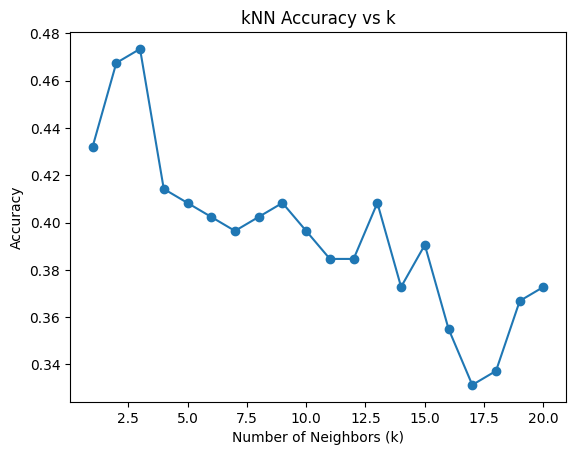

In [166]:
# Q2.3

# Test range of k values
k_values = range(1, 21)
accuracies = []

# Create list of accuracies at each k values
for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train_scaled, y_train)
    y_pred = knn.predict(X_test_scaled)
    acc = accuracy_score(y_test, y_pred)
    accuracies.append(acc)

plt.plot(k_values, accuracies, marker='o')
plt.xlabel("Number of Neighbors (k)")
plt.ylabel("Accuracy")
plt.title("kNN Accuracy vs k")
plt.show()



In [167]:
# Find the best k values within range of values
best_k = k_values[np.argmax(accuracies)]
best_k

# k should be one, because it yields highest accuracy by large margin and does
# not run much risk of overfitting

3

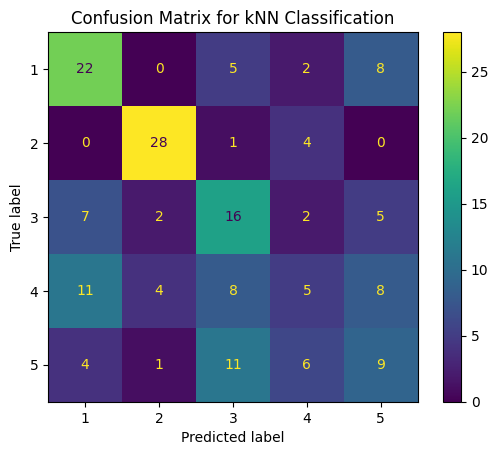

In [168]:
# Q2.4

# Build final model using best k value of 3
knn = KNeighborsClassifier(n_neighbors=best_k)
knn.fit(X_train_scaled, y_train)

y_pred = knn.predict(X_test_scaled)

# Create confusion matrix and display
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=knn.classes_
)
disp.plot()
plt.title("Confusion Matrix for kNN Classification")
plt.show()


In [169]:
# Calculate overall accuracy score
accuracy_score(y_test, y_pred)

0.47337278106508873

In [170]:
# Q2.5

# Considering the degree of error, I would advise the user of the model to
# be aware of any dangerous inaccuracies regarding mines that are difficult to
# diffuse or otherwise problematic. Perhaps this could help guide them as to
# which tools etc. to bring to the site so long as they are ready for anything.


**Q3.** This question is a case study for $k$ nearest neighbor regression, using the `USA_cars_datasets.csv` data.

The target variable `y` is `price` and the features are `year` and `mileage`.

1. Load the `./data/USA_cars_datasets.csv`. Keep the following variables and drop the rest: `price`, `year`, `mileage`. Are there any `NA`'s to handle? Look at the head and dimensions of the data.
2. Maxmin normalize `year` and `mileage`.
3. Split the sample into ~80% for training and ~20% for hyper-parameter selection and evaluation.
4. Use the $k$-NN algorithm and the training data to predict `price` using `year` and `mileage` for the test set for $k=3,10,25,50,100,300$. For each value of $k$, compute the mean squared error and print a scatterplot showing the test value plotted against the predicted value. What patterns do you notice as you increase $k$?
5. Determine the optimal $k$ for these data.
6. Describe what happened in the plots of predicted versus actual prices as $k$ varied, taking your answer into part 6 into account. (Hint: Use the words "underfitting" and "overfitting".)

In [171]:
# Q3.1

# Load in data
cars = pd.read_csv("data/USA_cars_datasets.csv")
cars = cars[['price', 'year', 'mileage']]

# Describe data
cars.describe()

,price,year,mileage
count,2499.000000,2499.000000,2.499000e+03
mean,18767.671469,2016.714286,5.229869e+04
std,12116.094936,3.442656,5.970552e+04
min,0.000000,1973.000000,0.000000e+00
25%,10200.000000,2016.000000,2.146650e+04
50%,16900.000000,2018.000000,3.536500e+04
75%,25555.500000,2019.000000,6.347250e+04
max,84900.000000,2020.000000,1.017936e+06


In [172]:
# Q3.2

# Normalize year and mileage
cars['year_norm'] = (cars['year'] - cars['year'].min()) / (cars['year'].max() - cars['year'].min())
cars['mileage_norm'] = (cars['mileage'] - cars['mileage'].min()) / (cars['mileage'].max() - cars['mileage'].min())

cars.head()


,price,year,mileage,year_norm,mileage_norm
0,6300,2008,274117,0.744681,0.269287
1,2899,2011,190552,0.808511,0.187194
2,5350,2018,39590,0.957447,0.038892
3,25000,2014,64146,0.872340,0.063016
4,27700,2018,6654,0.957447,0.006537


In [173]:
# Q3.3

# Define variables
X = cars[['year_norm', 'mileage_norm']]
y = cars['price']

# Create 80/20 train test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


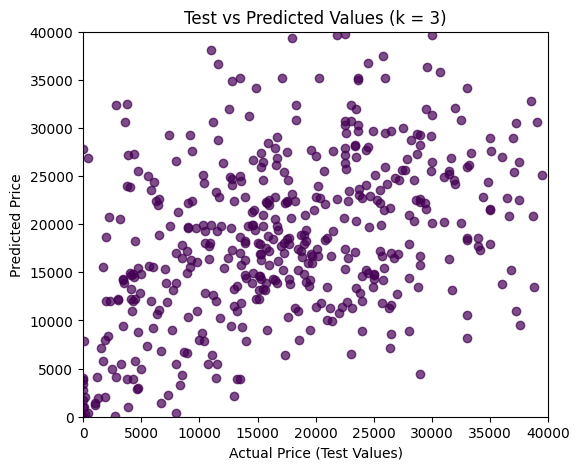

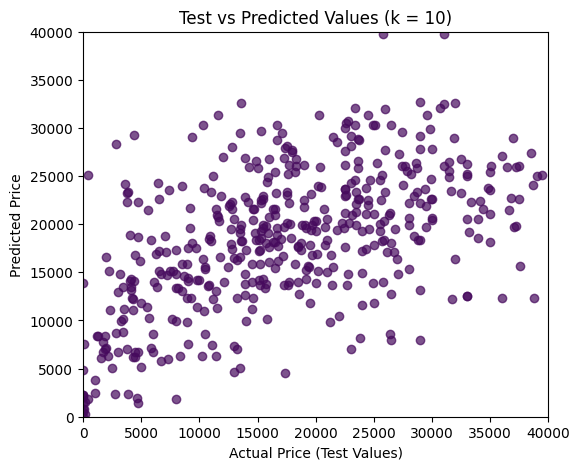

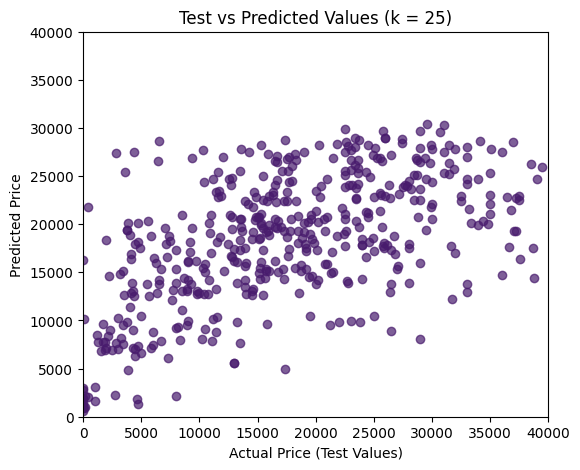

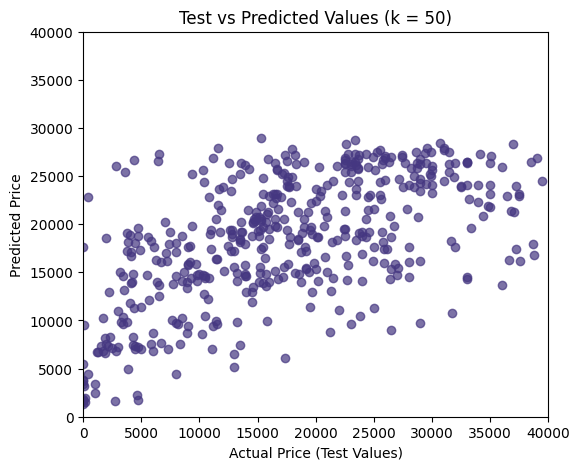

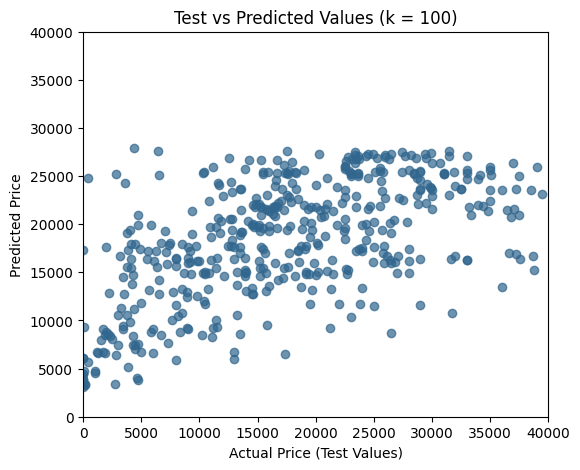

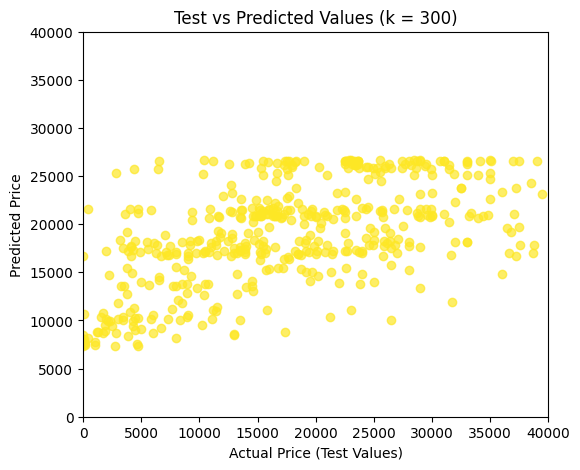

In [174]:
# Q3.4

# Create list of desired k values
k_values = [3, 10, 25, 50, 100, 300]
norm = plt.Normalize(min(k_values), max(k_values))
rmse_values = []

from matplotlib import cm

# Fit model and calculate RMSE for each k value
for k in k_values:
    knn = KNeighborsRegressor(n_neighbors=k)
    knn.fit(X_train, y_train)
    y_pred = knn.predict(X_test)

    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    rmse_values.append(rmse)

    plt.figure(figsize=(6, 5))
    plt.scatter(
        y_test,
        y_pred,
        c=[cm.viridis(norm(k))],
        alpha=0.7
    )
    plt.xlabel("Actual Price (Test Values)")
    plt.ylabel("Predicted Price")
    plt.xlim(0, 40000)
    plt.ylim(0, 40000)
    plt.title(f"Test vs Predicted Values (k = {k})")
    plt.show()

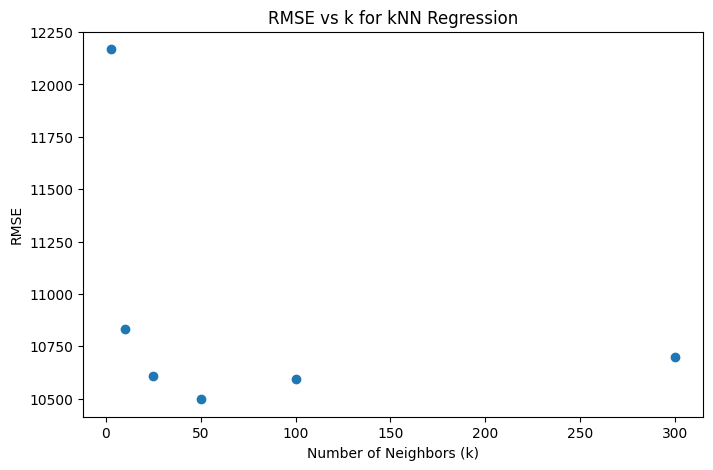

In [175]:
# Plot RMSE against k
plt.figure(figsize=(8,5))
plt.scatter(k_values, rmse_values)
plt.xlabel("Number of Neighbors (k)")
plt.ylabel("RMSE")
plt.title("RMSE vs k for kNN Regression")
plt.show()

# RMSE declines drastically with increase in k up to 50, then begins to increase
# again gradually

In [176]:
# Q3.5

# Find best k value
best_k = k_values[np.argmin(rmse_values)]
best_k


50

In [177]:
# Q3.6

# At smaller k values, the model was overfitted, with predictions all over the
# place as the model was not generalizable

# At larger k values, the model was underfitted, losing specificity as too many
# neighbors were used and cars tended to almost fall into categories


**Q6.** This is a case study using $k$ nearest neighbor regression for imputation, using the `airbnb_hw.csv` data.

There are 30,478 observations, but only 22,155 ratings. We're going to build a kNN regressor to impute missing values. This is a common task, and illustrates one way you can use kNN in the future even when you have more advanced models available.

1. Load the `airbnb_hw.csv` data with Pandas. We're only going to use `Review Scores Rating`, `Price`, and `Beds`, so use `.loc` to column filter the dataframe to those variables.
2. Set use `.isnull()` and `.loc` to select the subset of the dataframe with missing review values. Set those aside in a different dataframe. We'll make predictions about them later.
3. Use `df = df.dropna(axis = 0, how = 'any')` to eliminate any observations with missing values/NA's from the dataframe.
4. For the complete cases, create a $k$-NN model that uses the variables `Price` and `Beds` to predict `Review Scores Rating`. How do you choose $k$? (Hint: Train/test split, iterate over reasonable values of $k$ and find a value that minimizes SSE on the test split using predictions from the training set.)
5. Predict the missing ratings.
6. Do a kernel density plot of the training ratings and the predicted missing ratings. Do they look similar or not? Describe what you see.

In [178]:
# Q6.1

# Load data
bnb = pd.read_csv("data/airbnb_hw.csv")

bnb = bnb[['Review Scores Rating', 'Price', 'Beds']]

bnb['Price'] = (
    bnb['Price']
    .astype(str)
    .str.replace(',', '', regex=False)
    .astype(float)
)


bnb.describe()

,Review Scores Rating,Price,Beds
count,22155.000000,30478.000000,30393.000000
mean,91.993230,163.589737,1.530089
std,8.850373,197.785454,1.015359
min,20.000000,10.000000,0.000000
25%,89.000000,80.000000,1.000000
50%,94.000000,125.000000,1.000000
75%,100.000000,195.000000,2.000000
max,100.000000,10000.000000,16.000000


In [179]:
# Q6.2

# Drop null values from main dataset, separate values into missing dataframe
bnb_missing = bnb.loc[bnb['Review Scores Rating'].isnull()]
bnb_missing = bnb_missing.dropna(subset=['Price', 'Beds'])


In [180]:
# Q6.3

# Drop NAs from main dataset
bnb = bnb.dropna(axis=0, how='any')

bnb.head()


,Review Scores Rating,Price,Beds
4,96.0,549.0,3.0
5,100.0,149.0,1.0
6,100.0,250.0,1.0
7,94.0,90.0,1.0
8,90.0,270.0,2.0


In [181]:
# Q6.4

# Define variables
X = bnb[['Price', 'Beds']]
y = bnb['Review Scores Rating']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)


# Scale values
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


# Fit model
knn = KNeighborsRegressor(n_neighbors=5)
knn.fit(X_train_scaled, y_train)

# Calculate accuracies across range of k
rmse_values = []

for k in range(1, 30):
    knn = KNeighborsRegressor(n_neighbors=k)
    knn.fit(X_train_scaled, y_train)

    y_pred = knn.predict(X_test_scaled)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    rmse_values.append(rmse)

best_k = np.argmin(rmse_values) + 1

best_k

np.int64(29)

In [182]:
# Q6.5

# Fit predictive model using best_k
knn = KNeighborsRegressor(n_neighbors=best_k)
knn.fit(X_train_scaled, y_train)

# Create and scale missing data
X_missing = bnb_missing[['Price', 'Beds']]
X_missing_scaled = scaler.transform(X_missing)

# Impute values
imputed_values = knn.predict(X_missing_scaled)


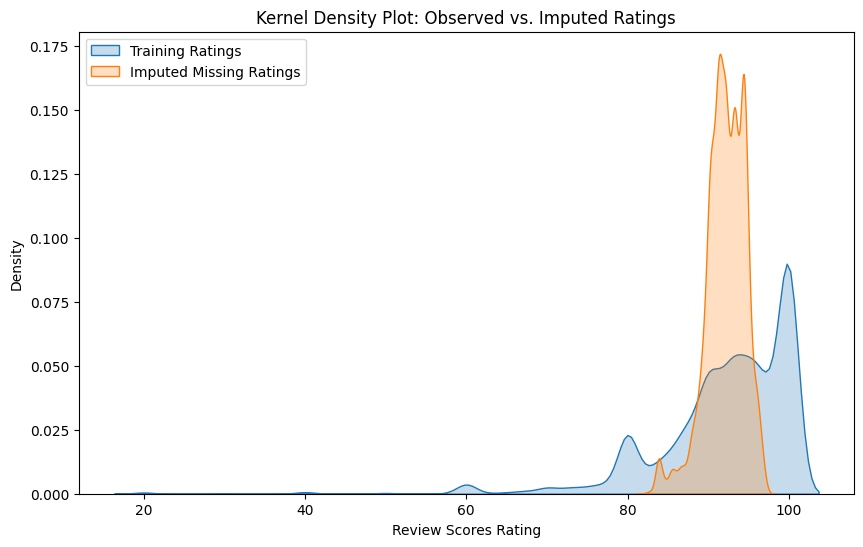

In [183]:
# Q6.6

plt.figure(figsize=(10,6))

# Kernel density plot of training ratings and imputed ratings
sns.kdeplot(y_train, fill=True, label='Training Ratings')
sns.kdeplot(imputed_values, fill=True, label='Imputed Missing Ratings')

plt.xlabel("Review Scores Rating")
plt.ylabel("Density")
plt.title("Kernel Density Plot: Observed vs. Imputed Ratings")
plt.legend()
plt.show()

# The two KDEs have a similar center, but the imputed ratings have a lower and
# more normal spread. This suggests that the prediction, especially at higher
# values of k will tend to predict values more close to the mean.